Objetivo: comparar modelos de classificação, selecionar o champion por validação cruzada, avaliar ranking, escolher threshold sem usar o holdout e interpretar o modelo final.


In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate,
    cross_val_predict, train_test_split
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SRC_PATH = Path('../src').resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from data_preprocessing import load_telco_data, split_xy, build_preprocessor
from metrics import ranking_metrics

RANDOM_STATE = 42


## Carregamento e split


In [2]:
DATA_PATH = Path('../data/raw/telco_customer_churn.xlsx')
df = load_telco_data(DATA_PATH)
X, y = split_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('Treino:', X_train.shape, f'churn={y_train.mean():.2%}')
print('Teste :', X_test.shape, f'churn={y_test.mean():.2%}')


Treino: (5634, 19) churn=35.16%
Teste : (1409, 19) churn=35.13%


## Pré-processamento


In [3]:
preprocessor = build_preprocessor(X_train)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Comparação de modelos com e sem balanceamento


In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

models = {
    'logistic': LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE),
    'logistic_balanced': LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(n_estimators=500, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'random_forest_balanced': RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
    'xgboost': XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    'xgboost_balanced': XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'roc_auc':'roc_auc','pr_auc':'average_precision','precision':'precision','recall':'recall','f1':'f1'}

rows = []
for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    rows.append(row)

comparison = pd.DataFrame(rows).sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)
comparison


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,logistic,0.628870,0.008904,0.449410,0.010904,0.504607,0.022656,0.159515,0.024808,0.241473,0.030230
1,logistic_balanced,0.628858,0.008570,0.449191,0.010780,0.432988,0.011698,0.709717,0.028382,0.537748,0.016001
2,xgboost_balanced,0.609503,0.007130,0.430731,0.017292,0.428620,0.007091,0.607772,0.023484,0.502395,0.005999
3,xgboost,0.609156,0.008716,0.429259,0.018709,0.448531,0.036923,0.173160,0.026159,0.249417,0.031848
4,random_forest,0.597794,0.011008,0.413869,0.015685,0.415916,0.049293,0.123174,0.015950,0.189799,0.022960
5,random_forest_balanced,0.597754,0.007716,0.414036,0.010851,0.427261,0.015476,0.281171,0.014503,0.338749,0.010159


## Tuning — Random Forest


In [5]:
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
rf_params = {
    'model__n_estimators':[300,500,800],
    'model__max_depth':[None,4,6,8,12],
    'model__min_samples_split':[2,5,10,20],
    'model__min_samples_leaf':[1,2,5,10],
    'model__max_features':['sqrt','log2',0.5],
    'model__class_weight':[None,'balanced','balanced_subsample'],
}
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params, n_iter=25, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1, refit=True
)
rf_search.fit(X_train, y_train)
print('Melhor ROC-AUC CV:', rf_search.best_score_)
rf_search.best_params_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Melhor ROC-AUC CV: 0.6265940466491783


{'model__n_estimators': 500,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 10,
 'model__max_features': 'log2',
 'model__max_depth': 4,
 'model__class_weight': 'balanced_subsample'}

## Tuning — XGBoost


In [6]:
xgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))
])
xgb_params = {
    'model__n_estimators':[200,300,400,600,800],
    'model__max_depth':[2,3,4,5,6],
    'model__learning_rate':[0.01,0.03,0.05,0.08,0.10],
    'model__min_child_weight':[1,3,5,8],
    'model__subsample':[0.7,0.8,0.9,1.0],
    'model__colsample_bytree':[0.7,0.8,0.9,1.0],
    'model__gamma':[0.0,0.1,0.3],
    'model__reg_alpha':[0.0,0.01,0.1],
    'model__reg_lambda':[1.0,2.0,5.0],
    'model__scale_pos_weight':[1.0,spw],
}
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_params, n_iter=30, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1, refit=True
)
xgb_search.fit(X_train, y_train)
print('Melhor ROC-AUC CV:', xgb_search.best_score_)
xgb_search.best_params_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhor ROC-AUC CV: 0.625715469437212


{'model__subsample': 0.7,
 'model__scale_pos_weight': np.float64(1.8440181726400808),
 'model__reg_lambda': 2.0,
 'model__reg_alpha': 0.01,
 'model__n_estimators': 300,
 'model__min_child_weight': 5,
 'model__max_depth': 3,
 'model__learning_rate': 0.01,
 'model__gamma': 0.0,
 'model__colsample_bytree': 0.8}

## Comparação final dos candidatos


In [7]:
best_base_name = comparison.iloc[0]['model']
best_base_pipe = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', models[best_base_name])
])

candidates = {
    best_base_name: best_base_pipe,
    'random_forest_tuned': rf_search.best_estimator_,
    'xgboost_tuned': xgb_search.best_estimator_,
}

candidate_rows = []
for name, pipe in candidates.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    candidate_rows.append({
        'model': name,
        'roc_auc_cv': scores['test_roc_auc'].mean(),
        'pr_auc_cv': scores['test_pr_auc'].mean(),
        'f1_cv': scores['test_f1'].mean(),
    })

final_comparison = pd.DataFrame(candidate_rows).sort_values('roc_auc_cv', ascending=False).reset_index(drop=True)
final_comparison


,model,roc_auc_cv,pr_auc_cv,f1_cv
0,logistic,0.628870,0.449410,0.241473
1,random_forest_tuned,0.626594,0.452644,0.547133
2,xgboost_tuned,0.625715,0.450652,0.543154


## Seleção do champion


In [8]:
champion_name = final_comparison.iloc[0]['model']
champion = candidates[champion_name]
print('Champion:', champion_name)


Champion: logistic


## Threshold usando apenas treino (OOF)

O ponto de corte é escolhido com previsões *out-of-fold* do conjunto de treino. Assim, o holdout permanece reservado para avaliação final.


In [9]:
oof_prob = cross_val_predict(
    champion, X_train, y_train, cv=cv, method='predict_proba', n_jobs=1
)[:,1]

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.01):
    pred = (oof_prob >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_train, pred, zero_division=0),
        'recall': recall_score(y_train, pred, zero_division=0),
        'f1': f1_score(y_train, pred, zero_division=0),
        'percentual_base_acionada': pred.mean(),
    })

threshold_table_train = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_table_train.loc[threshold_table_train['f1'].idxmax()]
best_threshold_row


threshold                   0.260000
precision                   0.419505
recall                      0.820798
f1                          0.555233
percentual_base_acionada    0.687966
Name: 6, dtype: float64

## Avaliação final no holdout


In [10]:
selected_threshold = float(best_threshold_row['threshold'])
champion.fit(X_train, y_train)
y_prob = champion.predict_proba(X_test)[:,1]
y_pred = (y_prob >= selected_threshold).astype(int)

test_metrics = {
    'roc_auc': roc_auc_score(y_test, y_prob),
    'pr_auc': average_precision_score(y_test, y_prob),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'threshold': selected_threshold,
}
pd.Series(test_metrics, name='holdout').to_frame()


,holdout
roc_auc,0.627469
pr_auc,0.446335
accuracy,0.529454
precision,0.414634
recall,0.824242
f1,0.551724
threshold,0.260000


In [11]:
print(classification_report(y_test, y_pred, target_names=['Não Churn','Churn'], zero_division=0))


              precision    recall  f1-score   support

   Não Churn       0.80      0.37      0.50       914
       Churn       0.41      0.82      0.55       495

    accuracy                           0.53      1409
   macro avg       0.60      0.60      0.53      1409
weighted avg       0.66      0.53      0.52      1409



## Matriz de confusão, ROC e Precision-Recall


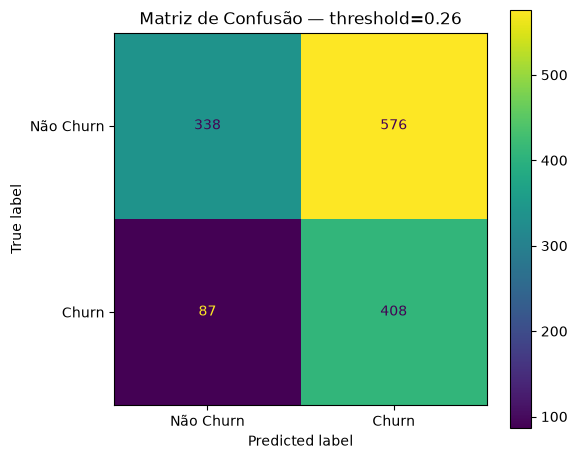

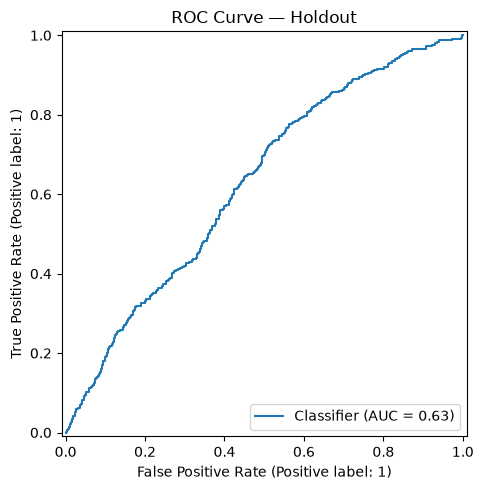

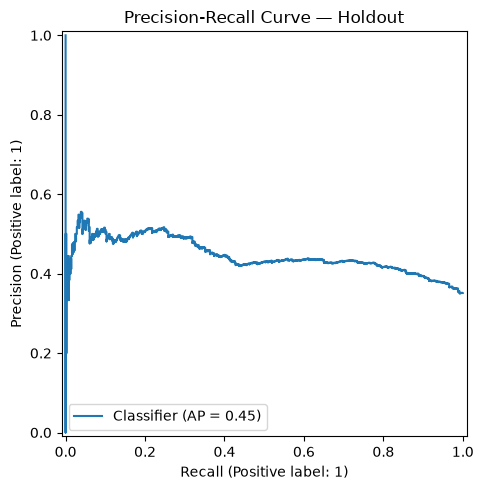

In [12]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Não Churn','Churn'], ax=ax)
ax.set_title(f'Matriz de Confusão — threshold={selected_threshold:.2f}')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title('ROC Curve — Holdout')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title('Precision-Recall Curve — Holdout')
plt.tight_layout(); plt.show()


## Lift@K e Capture Rate@K


In [13]:
ranking_table = ranking_metrics(y_test, y_prob)
ranking_table


,top_pct,clientes,churn_rate_top,lift,capture_rate
0,0.05,71,0.492958,1.403187,0.070707
1,0.10,141,0.489362,1.392951,0.139394
2,0.20,282,0.492908,1.403045,0.280808
3,0.30,423,0.446809,1.271825,0.381818
4,0.40,564,0.423759,1.206215,0.482828


## SHAP


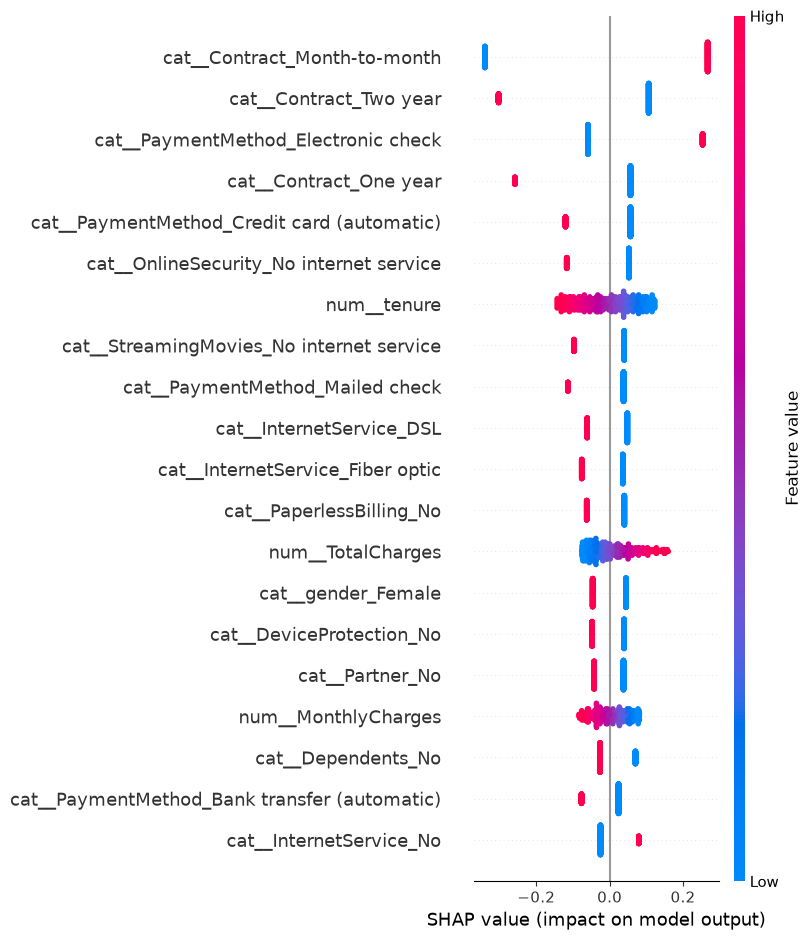

In [ ]:
prep = champion.named_steps['preprocessor']
estimator = champion.named_steps['model']
sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
Xt = prep.transform(sample)
if hasattr(Xt, 'toarray'):
    Xt = Xt.toarray()
feature_names = prep.get_feature_names_out()
model_class = estimator.__class__.__name__.lower()

if 'xgb' in model_class or 'forest' in model_class:
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(Xt)
    if isinstance(shap_values, list):
        shap_values = shap_vaylues[-1]
else:
    explainer = shap.LinearExplainer(estimator, Xt)
    shap_values = explainer.shap_values(Xt)

shap.summary_plot(shap_values, Xt, feature_names=feature_names, max_display=20)


# Conclusões da Modelagem

Foram avaliados diferentes algoritmos de classificação, Regressão Logística, Random Forest e XGBoost, além de versões com ponderação de classes. A seleção do modelo foi realizada utilizando ROC-AUC médio em validação cruzada estratificada com 5 folds, mantendo o conjunto de teste separado para avaliação final. A Regressão Logística sem balanceamento apresentou o melhor desempenho médio, com ROC-AUC de aproximadamente 0,6289 em cross-validation.

Os modelos mais complexos não apresentaram ganho consistente. Após tuning de hiperparâmetros:
- Random Forest: ROC-AUC CV de aproximadamente 0,6266;
- XGBoost: ROC-AUC CV de aproximadamente 0,6257.

Dessa forma, a Regressão Logística foi selecionada como champion.

No holdout, o modelo apresentou ROC-AUC de aproximadamente 0,6275 e PR-AUC de 0,4463, resultados muito próximos aos observados em validação cruzada, indicando estabilidade da avaliação. A análise de threshold mostrou que o ponto de corte padrão de 0,50 não é necessariamente o mais adequado para o problema de retenção. Thresholds menores aumentam significativamente o recall, porém também ampliam a quantidade de clientes classificados como risco.
Por esse motivo, o threshold de produção deve ser definido considerando não apenas métricas estatísticas, mas também capacidade operacional, custo da campanha, valor esperado do cliente e custo associado a falsos positivos e falsos negativos.

Na avaliação de ranking, o modelo apresentou Lift@10% de aproximadamente 1,39x e Lift@20% de aproximadamente 1,40x, indicando capacidade moderada de concentrar churners nas primeiras posições do ranking. As features derivadas testadas não trouxeram ganho consistente de performance, portanto optou-se por manter a solução mais simples.